# day-11-model-tradeoffs — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

In [10]:
# ---- Solution 1 ----
def cheapest_clearing(bar):
    ok = [(cost_per_call(m), m) for m in MODELS if MODELS[m]["acc"] >= bar]
    return min(ok)[1] if ok else None
for bar in [0.80, 0.88, 0.93, 0.96]:
    print(f"bar {bar}: {cheapest_clearing(bar)}")

bar 0.8: small
bar 0.88: mid
bar 0.93: large
bar 0.96: frontier


In [11]:
# ---- Solution 2 ----
order = ["nano","small","mid","large","frontier"]
for a, b in zip(order, order[1:]):
    dacc = MODELS[b]["acc"] - MODELS[a]["acc"]
    dcost = cost_per_call(b) - cost_per_call(a)
    print(f"{a:>8} -> {b:<8}  +{dacc:.3f} acc  +${dcost*1000:.3f}/1k  = ${dcost/dacc*1000:.2f} per point per 1k calls")
print("-> the large->frontier hop is by far the most expensive accuracy.")

    nano -> small     +0.120 acc  +$0.180/1k  = $1.50 per point per 1k calls
   small -> mid       +0.070 acc  +$0.505/1k  = $7.21 per point per 1k calls
     mid -> large     +0.045 acc  +$5.375/1k  = $119.44 per point per 1k calls
   large -> frontier  +0.017 acc  +$11.850/1k  = $697.06 per point per 1k calls
-> the large->frontier hop is by far the most expensive accuracy.


In [12]:
# ---- Solution 3 ----
for m in MODELS:
    s = sample_latency(m)
    p95 = np.percentile(s, 95)
    print(f"{m:10s} p95 total {p95:.2f}s  {'PASS' if p95 < 2.5 else 'fail'}   "
          f"ttft~{MODELS[m]['ttft']*1.5:.2f}s  {'stream-PASS' if MODELS[m]['ttft']*1.5 < 0.6 else 'stream-fail'}")

nano       p95 total 1.12s  PASS   ttft~0.30s  stream-PASS
small      p95 total 1.40s  PASS   ttft~0.38s  stream-PASS
mid        p95 total 1.96s  PASS   ttft~0.52s  stream-PASS
large      p95 total 3.25s  fail   ttft~0.83s  stream-fail
frontier   p95 total 5.73s  fail   ttft~1.35s  stream-fail
legacy     p95 total 3.91s  fail   ttft~1.05s  stream-fail


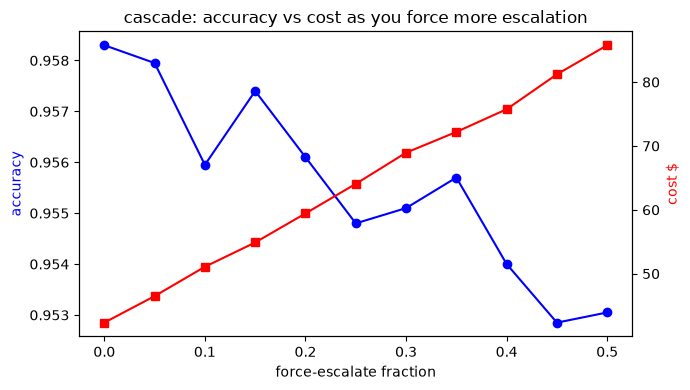

In [13]:
# ---- Solution 5 ----
fracs = np.linspace(0, 0.5, 11)
accs, costs = [], []
for f in fracs:
    a, c, _ = run_cascade("small", "large", force_escalate_frac=f)
    accs.append(a); costs.append(c)
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(fracs, accs, "b-o", label="accuracy"); ax1.set_xlabel("force-escalate fraction")
ax1.set_ylabel("accuracy", color="b")
ax2 = ax1.twinx(); ax2.plot(fracs, costs, "r-s"); ax2.set_ylabel("cost $", color="r")
plt.title("cascade: accuracy vs cost as you force more escalation"); plt.tight_layout(); plt.show()

In [14]:
# ---- Solution 6 ----
def run_cascade_oracle(cheap, expensive):
    cheap_ok = rng.random(N) < MODELS[cheap]["acc"]   # would the cheap model be right?
    esc = ~cheap_ok                                   # escalate exactly when it would be wrong
    ok = cheap_ok.copy()
    ok[esc] = rng.random(esc.sum()) < MODELS[expensive]["acc"]
    cost = cost_per_call(cheap)*N + cost_per_call(expensive)*esc.sum()
    return ok.mean(), cost, esc.mean()

o_a, o_c, o_esc = run_cascade_oracle("small", "large")
n_a, n_c, n_esc = run_cascade("small", "large")
print(f"oracle confidence : acc {o_a:.3f}  cost ${o_c:.2f}  escalated {o_esc:.0%}")
print(f"noisy  confidence : acc {n_a:.3f}  cost ${n_c:.2f}  escalated {n_esc:.0%}")
print("-> better confidence estimation is worth real money; it's why logprob calibration and")
print("   lightweight verifier models are an active area.")

oracle confidence : acc 0.991  cost $25.92  escalated 17%
noisy  confidence : acc 0.959  cost $42.28  escalated 30%
-> better confidence estimation is worth real money; it's why logprob calibration and
   lightweight verifier models are an active area.


### Solution 4 (worked)

`large` input cost per call = `800 · 3.00 / 1e6 = $0.0024`. A 70% cache hit at 90% discount
saves `0.7 · 0.0024 · 0.9 = $0.001512` per call. Break-even vs a $12,000/month engineer:
`12000 / 0.001512 ≈ 7.9M calls/month`. Below that, the cache is still free money — it just
isn't "worth an engineer" until ~8M calls/month.

### Answer key
1. `cost = (in_tokens · price_in + out_tokens · price_out)`, prices in $/token (or $/1e6
   tokens with a `/1e6`).
2. Another model is ≥ on every axis (accuracy, cost, latency) and strictly better on at least
   one. Remove it from consideration — it's never the rational pick.
3. Users experience the tail; a good median with a bad p95 means a meaningful fraction of
   requests feel broken. SLAs and user perception track the tail.
4. Streaming shows the first token at TTFT, so a model with a fast first token but slow total
   generation can still feel responsive and pass a "first token < Xs" budget even if its p95
   *total* would fail a non-streaming budget.
5. Run the cheap model first; if its confidence signal says it's likely right, ship that,
   otherwise escalate to a bigger model. Precondition: a usable cheap confidence signal (and a
   task with many easy cases).
6. Ship `mid`. Redirect the ~13× cost savings to volume headroom, a cascade for the hard tail,
   retries, evals, or just margin — don't pay for accuracy you don't need.
7. The input / prefix (stable system prompt, few-shot examples, RAG preamble). Make it
   effective by putting the unchanging content first so the provider can cache a long prefix.